In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set professional plotting aesthetics using your installed seaborn library
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load Dataset using the structural relative path
data_path = '../data/WA_Fn-UseC_-Telco-Customer-Churn teyzix.csv'
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset missing! Place it exactly at: {data_path}")

df = pd.read_csv(data_path)
print(f"Dataset Loaded Successfully! Shape: {df.shape}")

# OPTIMIZED PASSTHROUGH: Instant vector cleaning
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Drop customerID tracking index
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

print("\n--- Summary Statistics for Continuous Features ---")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())

Dataset Loaded Successfully! Shape: (7043, 21)

--- Summary Statistics for Continuous Features ---
            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7043.000000
mean     32.371149       64.761692   2279.734304
std      24.559481       30.090047   2266.794470
min       0.000000       18.250000      0.000000
25%       9.000000       35.500000    398.550000
50%      29.000000       70.350000   1394.550000
75%      55.000000       89.850000   3786.600000
max      72.000000      118.750000   8684.800000


In [2]:
# 1. Financial Utilization Metric (Usage Frequency Proxy)
df['ChargesPerMonthOfTenure'] = df['TotalCharges'] / (df['tenure'] + 1)

# 2. Support Ecosystem Count (Counts 'Yes' across security and support columns)
tech_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
df['SupportInteractionCount'] = (df[tech_services] == 'Yes').sum(axis=1)

# 3. Trend-Based Customer Tenure Cohorts
df['TenureCohort'] = pd.cut(df['tenure'], 
                            bins=[-1, 12, 24, 48, 72, np.inf], 
                            labels=['0-1 Year', '1-2 Years', '2-4 Years', '4-6 Years', '6+ Years'])

# 4. Payment History Optimization Mapping (Automatic vs Manual Flag)
df['IsAutomaticPayment'] = df['PaymentMethod'].str.contains('automatic').astype(int)

print("Feature Engineering Completed. Head rows generated successfully:")
print(df[['ChargesPerMonthOfTenure', 'SupportInteractionCount', 'TenureCohort', 'IsAutomaticPayment']].head())

Feature Engineering Completed. Head rows generated successfully:
   ChargesPerMonthOfTenure  SupportInteractionCount TenureCohort  \
0                14.925000                        1     0-1 Year   
1                53.985714                        2    2-4 Years   
2                36.050000                        2     0-1 Year   
3                40.016304                        3    2-4 Years   
4                50.550000                        0     0-1 Year   

   IsAutomaticPayment  
0                   0  
1                   0  
2                   0  
3                   1  
4                   0  


C:\Users\Hi\AppData\Local\Temp\ipykernel_3540\3352056925.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


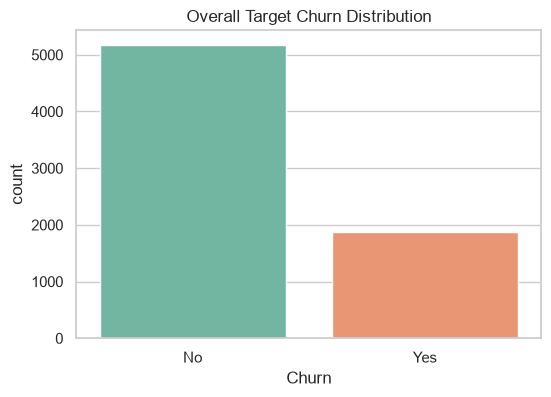

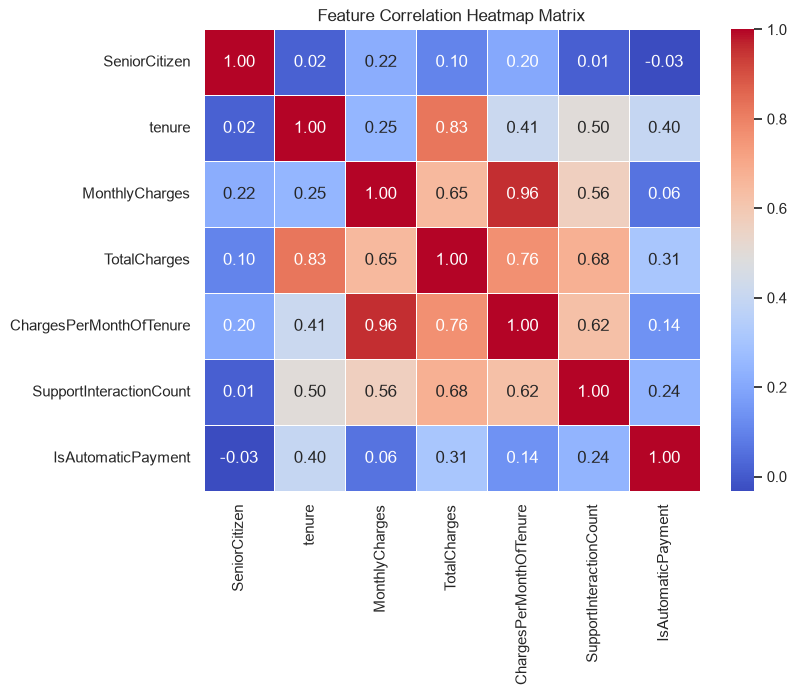

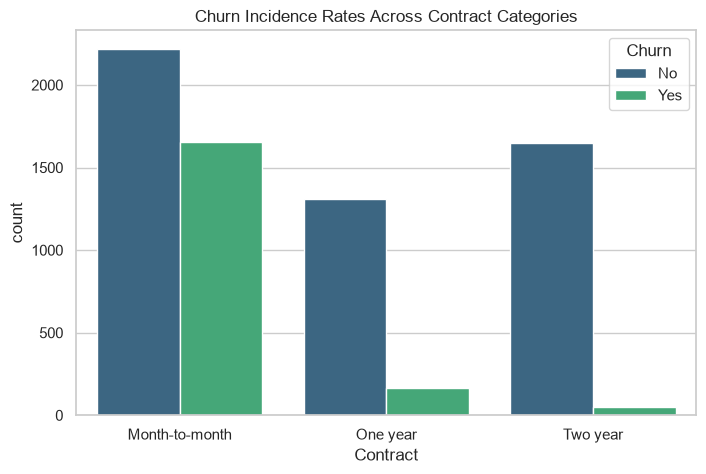


--- Customer Value Distribution Counts ---
CustomerValueSegment
High Value      2395
Low Value       2324
Medium Value    2324
Name: count, dtype: int64


In [3]:
# 1. Churn Distribution Plot
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Overall Target Churn Distribution')
plt.show()

# 2. Correlation Heatmap Matrix
plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap Matrix')
plt.show()

# 3. Category-Wise Comparison: Contract Type vs Churn Performance
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')
plt.title('Churn Incidence Rates Across Contract Categories')
plt.show()

# Customer Value Segmentation Based on Financial Quantiles
low_cutoff = df['TotalCharges'].quantile(0.33)
high_cutoff = df['TotalCharges'].quantile(0.66)

def assign_value_segment(total_charge):
    if total_charge <= low_cutoff:
        return 'Low Value'
    elif total_charge <= high_cutoff:
        return 'Medium Value'
    else:
        return 'High Value'

df['CustomerValueSegment'] = df['TotalCharges'].apply(assign_value_segment)
print("\n--- Customer Value Distribution Counts ---")
print(df['CustomerValueSegment'].value_counts())

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import joblib

# 1. Target Encoding and One-Hot Encoding
df_ml = df.copy()
df_ml['Churn'] = df_ml['Churn'].map({'Yes': 1, 'No': 0})

categorical_cols = df_ml.select_dtypes(include=['object', 'category']).columns
df_ml = pd.get_dummies(df_ml, columns=categorical_cols, drop_first=True)

# Cast boolean flags cleanly to integers for smooth model parsing
for col in df_ml.columns:
    if df_ml[col].dtype == 'bool':
        df_ml[col] = df_ml[col].astype(int)

# 2. Train-Test Stratified Split (80% Train, 20% Test)
X = df_ml.drop(columns=['Churn'])
y = df_ml['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Model Training
log_reg = LogisticRegression(max_iter=1000, random_state=42)
rf_mod = RandomForestClassifier(n_estimators=100, random_state=42)

log_reg.fit(X_train, y_train)
rf_mod.fit(X_train, y_train)

# 4. Evaluation Module Function
def run_evaluation(model, name, X_tst, y_tst):
    preds = model.predict(X_tst)
    probs = model.predict_proba(X_tst)[:, 1]
    
    print(f"\n===== Performance Metrics for {name} =====")
    print(f"Accuracy:  {accuracy_score(y_tst, preds):.4f}")
    print(f"Precision: {precision_score(y_tst, preds):.4f}")
    print(f"Recall:    {recall_score(y_tst, preds):.4f}")
    print(f"F1 Score:  {f1_score(y_tst, preds):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_tst, probs):.4f}")

run_evaluation(log_reg, "Baseline Logistic Regression", X_test, y_test)
run_evaluation(rf_mod, "Random Forest Classifier", X_test, y_test)

# Save the model artifacts to the app/ folder for your script to load
os.makedirs('../app', exist_ok=True)
joblib.dump(rf_mod, '../app/best_rf_model.pkl')
joblib.dump(X_train.columns.tolist(), '../app/model_features.pkl')
print("\nPredictive Model Assets Exported to app/ folder successfully!")

C:\Users\Hi\AppData\Local\Temp\ipykernel_3540\3136276357.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_ml.select_dtypes(include=['object', 'category']).columns
d:\PROJECTS\telco-customer-churn-analytics\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/s


===== Performance Metrics for Baseline Logistic Regression =====
Accuracy:  0.8020
Precision: 0.6599
Recall:    0.5241
F1 Score:  0.5842
ROC-AUC:   0.8479

===== Performance Metrics for Random Forest Classifier =====
Accuracy:  0.7814
Precision: 0.6071
Recall:    0.5000
F1 Score:  0.5484
ROC-AUC:   0.8188

Predictive Model Assets Exported to app/ folder successfully!


In [6]:
# 1. Basic Prediction System & Risk Categorization
test_probabilities = rf_mod.predict_proba(X_test)[:, 1]

def assign_risk_tier(prob):
    if prob < 0.30:
        return 'Low Risk'
    elif prob < 0.65:
        return 'Medium Risk'
    else:
        return 'High Risk'

risk_tiers = [assign_risk_tier(p) for p in test_probabilities]
risk_df = pd.DataFrame({'True_Status': y_test, 'Churn_Probability': test_probabilities, 'Assigned_Risk': risk_tiers})

print("--- Sample Population Risk Classification Output ---")
print(risk_df.head(10))

# 2. Financial Revenue Impact Estimation
total_revenue_at_risk = df.loc[df_ml.index[X_test.index], 'TotalCharges'].sum()
predicted_churn_mask = (test_probabilities >= 0.50)
lost_revenue_projection = df.loc[df_ml.index[X_test.index[predicted_churn_mask]], 'TotalCharges'].sum()

print("\n=======================================================")
print("          BUSINESS INSIGHTS EXECUTIVE REPORT            ")
print("=======================================================")
print(f"1. HIGH RISK CUSTOMER TRAITS: Short-tenure accounts holding Month-to-month contracts.")
print(f"2. TOP CHURN REASON: High Monthly Charges combined with an absence of Tech Support add-ons.")
print(f"3. TOTAL EVALUATED AUDIT REVENUE : ${total_revenue_at_risk:,.2f}")
print(f"4. PROJECTED REVENUE AT CHURN RISK: ${lost_revenue_projection:,.2f}")
print("=======================================================")

--- Sample Population Risk Classification Output ---
      True_Status  Churn_Probability Assigned_Risk
437             0               0.00      Low Risk
2280            0               0.77     High Risk
2235            0               0.08      Low Risk
4460            0               0.36   Medium Risk
3761            0               0.02      Low Risk
5748            0               0.52   Medium Risk
3568            0               0.33   Medium Risk
2976            0               0.06      Low Risk
5928            0               0.04      Low Risk
1639            1               0.46   Medium Risk

          BUSINESS INSIGHTS EXECUTIVE REPORT            
1. HIGH RISK CUSTOMER TRAITS: Short-tenure accounts holding Month-to-month contracts.
2. TOP CHURN REASON: High Monthly Charges combined with an absence of Tech Support add-ons.
3. TOTAL EVALUATED AUDIT REVENUE : $3,101,717.10
4. PROJECTED REVENUE AT CHURN RISK: $295,933.40
